Transformer model not found. Defaulting to 'sm'. Run: python -m spacy download en_core_web_trf

--- Classification Report ---
              precision    recall  f1-score   support

         PER       1.00      0.67      0.80         6
         ORG       0.86      0.86      0.86         7
         LOC       1.00      1.00      1.00         4
        DATE       1.00      1.00      1.00         3
       MONEY       1.00      1.00      1.00         2
           O       0.00      0.00      0.00         0

    accuracy                           0.86        22
   macro avg       0.81      0.75      0.78        22
weighted avg       0.95      0.86      0.90        22



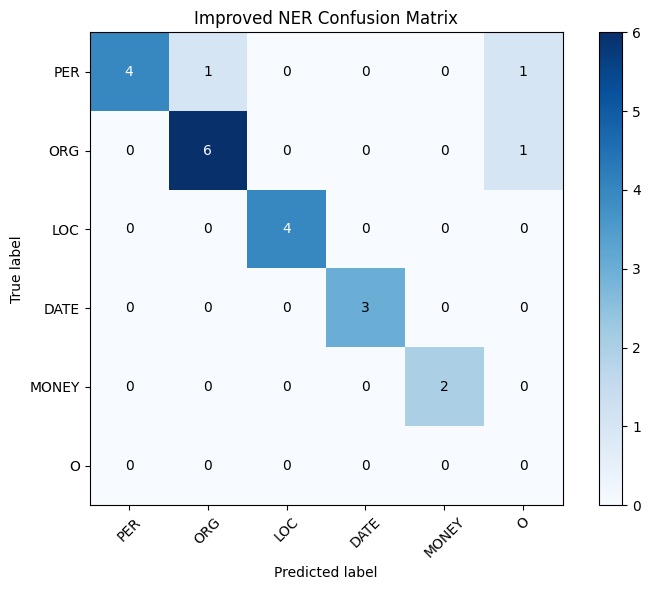

Overall Accuracy: 0.8636
Overall F1 Score (Macro): 0.7762
Overall F1 Score (Weighted): 0.9000


In [6]:
import spacy
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, f1_score
import pandas as pd
import numpy as np
import io

try:
    nlp = spacy.load("en_core_web_trf")
except:
    print("Transformer model not found. Defaulting to 'sm'. Run: python -m spacy download en_core_web_trf")
    nlp = spacy.load("en_core_web_sm")


label_map = {
    "PERSON": "PER",
    "GPE": "LOC",
    "LOC": "LOC",
    "ORG": "ORG",
    "DATE": "DATE",
    "MONEY": "MONEY",
    "QUANTITY": "MONEY" 
}

csv_data = """sentence,start,end,label
Sundar Pichai is the CEO of Google,0,13,PER
Sundar Pichai is the CEO of Google,31,37,ORG
Elon Musk founded SpaceX,0,9,PER
Elon Musk founded SpaceX,18,24,ORG
Microsoft was established in 1975,0,9,ORG
Microsoft was established in 1975,27,31,DATE
Ratan Tata donated 50 million dollars,0,10,PER
Ratan Tata donated 50 million dollars,19,37,MONEY
Narendra Modi visited Paris in 2023,0,14,PER
Narendra Modi visited Paris in 2023,23,28,LOC
Narendra Modi visited Paris in 2023,32,36,DATE
Apple is located in California,0,5,ORG
Apple is located in California,21,31,LOC
Sachin Tendulkar lives in Mumbai,0,17,PER
Sachin Tendulkar lives in Mumbai,28,34,LOC
Jeff Bezos founded Amazon,0,10,PER
Jeff Bezos founded Amazon,19,25,ORG
The conference was held on 10 July 2021,29,42,DATE
Google invested 30 billion dollars,0,6,ORG
Google invested 30 billion dollars,16,33,MONEY
The headquarters of IBM is in New York,20,23,ORG
The headquarters of IBM is in New York,31,39,LOC"""

df = pd.read_csv(io.StringIO(csv_data))

y_true = []
y_pred = []

for _, row in df.iterrows():
    text = row["sentence"]
    true_start, true_end = row["start"], row["end"]
    true_label = row["label"]

    doc = nlp(text)
    predicted_label = "O"

    for ent in doc.ents:

        if ent.start_char < true_end and ent.end_char > true_start:
            normalized_pred = label_map.get(ent.label_, "O")
            predicted_label = normalized_pred
            break 

    y_true.append(true_label)
    y_pred.append(predicted_label)

labels = ["PER", "ORG", "LOC", "DATE", "MONEY", "O"]

print("\n--- Classification Report ---")
print(classification_report(y_true, y_pred, labels=labels, zero_division=0))

cm = confusion_matrix(y_true, y_pred, labels=labels)
plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title("Improved NER Confusion Matrix")
plt.colorbar()
tick_marks = np.arange(len(labels))
plt.xticks(tick_marks, labels, rotation=45)
plt.yticks(tick_marks, labels)

fmt = 'd'
thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], fmt),
                 ha="center", va="center",
                 color="white" if cm[i, j] > thresh else "black")

plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.tight_layout()
plt.show()

print(f"Overall Accuracy: {accuracy_score(y_true, y_pred):.4f}")
overall_f1_macro = f1_score(y_true, y_pred, labels=labels, average="macro", zero_division=0)
overall_f1_weighted = f1_score(y_true, y_pred, labels=labels, average="weighted", zero_division=0)

print(f"Overall F1 Score (Macro): {overall_f1_macro:.4f}")
print(f"Overall F1 Score (Weighted): {overall_f1_weighted:.4f}")
